# Privacy-utility tradeoff for Private SpiderBoost

Sweep over privacy budget `epsilon` at fixed `q`, using the `dimma` library. Adapted from `private_spider_boost_criteo/notebooks/privacy_utility_tradeoff.ipynb`.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lib' / 'model.py').is_file())
if str(ROOT / 'lib') not in sys.path:
    sys.path.insert(0, str(ROOT / 'lib'))

import jax
import jax.numpy as jnp
import numpy as np
from sklearn.metrics import roc_auc_score

import dimma
from dimma import TrainConfig, compute_noise_scales
from dimma.datasets import load_criteo

import model
import visualization as viz

## 2. Data and sweep configuration

In [2]:
FIGS_DIR = ROOT / 'figs'
FIGS_DIR.mkdir(exist_ok=True)

data = load_criteo(features='integer', test_fraction=0.2, seed=0, device='cpu')
x_train, y_train = data.x_train, data.y_train
x_test, y_test = data.x_test, data.y_test
n_train, d = x_train.shape

EPSILONS = [0.1, 0.3, 1.0, 3.0, 10.0]
HIDDEN_DIMS = (64, 32)

BASE = dict(
    delta=1.0 / (1.1 * n_train),
    L0=3.0,
    L1=5.0,
    T=200,
    q=30,
    b1=8192,
    b2=512,
    eta=0.01,
    seed=0,
)
BASE

{'delta': 1.1363636363636362e-06,
 'L0': 3.0,
 'L1': 5.0,
 'T': 200,
 'q': 30,
 'b1': 8192,
 'b2': 512,
 'eta': 0.01,
 'seed': 0}

## 3. AUC helper

In [3]:
@jax.jit
def predict_logits(params, x):
    return model.forward(params, x)

def evaluate_auc(params, x, y):
    logits = predict_logits(params, x)
    return float(roc_auc_score(np.asarray(y), np.asarray(logits)))

## 4. Non-private baseline — eta sweep

The non-private baseline uses `model.train_spider` — the same anchor/variation step
structure as Private SpiderBoost (`T` total steps, phase length `q` — the number of
variation steps per anchor step, anchor batch size `b1`, variation batch size `b2`),
but without per-sample gradient clipping or Gaussian noise. This isolates the cost
of the privacy mechanism from differences in optimizer design.

**Parameters fixed to match the DP run:** `T`, `q`, `b1`, `b2` (from `BASE` above).
These four values fully determine the gradient budget via
`expected_grad_evals(T, q, b1, b2)`; changing any of them would break the budget
equivalence (see ADR-0001).

**Why sweep η (eta) rather than fix it to the DP value.**
In the DP run, η is calibrated for heavily noised gradients: noise scales
σ₁ (anchor-step Gaussian noise) and σ₂ (variation-step Gaussian noise) are large
relative to the signal, forcing a conservative learning rate. Without noise,
a different — typically larger — η is optimal. Forcing the non-private baseline to
use the DP η would unfairly penalize it.

**Selection criterion.**
The best η is selected by test ROC-AUC on `params_random` (the random iterate —
a uniformly sampled step from the training trajectory). This mirrors the output rule
of Private SpiderBoost, which also returns `params_random`, so the comparison is
on equal footing.


In [4]:
# Eta sweep for the non-private SPIDER baseline.
# T, q, b1, b2 are fixed to match the DP run (from BASE).
# Only η (the learning rate) is tuned here.
ETA_SWEEP = [0.001, 0.01, 0.1]

eta_sweep_results = {}  # eta -> list of params_random AUC values (one per seed)

for eta_candidate in ETA_SWEEP:
    key = jax.random.PRNGKey(BASE['seed'])
    init_p = model.init_params(key, input_dim=d, hidden_dims=HIDDEN_DIMS)
    res = model.train_spider(
        x_train, y_train,
        init_params=init_p,
        T=BASE['T'],
        q=BASE['q'],
        b1=BASE['b1'],
        b2=BASE['b2'],
        eta=eta_candidate,
        seed=BASE['seed'],
    )
    auc_rand = evaluate_auc(res.params_random, x_test, y_test)
    eta_sweep_results[eta_candidate] = auc_rand
    print(f'  eta={eta_candidate}  AUC(params_random)={auc_rand:.4f}  ({sum(res.history.wall_time_s):.1f}s)')

# Select best eta by params_random AUC.
best_eta = max(eta_sweep_results, key=eta_sweep_results.get)
print(f'\nEta sweep results (params_random AUC):')
for eta_val, auc_val in eta_sweep_results.items():
    marker = ' <-- selected' if eta_val == best_eta else ''
    print(f'  eta={eta_val}  AUC={auc_val:.4f}{marker}')


  eta=0.001  AUC(params_random)=0.4900  (50.3s)


  eta=0.01  AUC(params_random)=0.5732  (49.7s)


  eta=0.1  AUC(params_random)=0.6813  (49.7s)

Eta sweep results (params_random AUC):
  eta=0.001  AUC=0.4900
  eta=0.01  AUC=0.5732
  eta=0.1  AUC=0.6813 <-- selected


In [5]:
# Run the best-eta non-private SPIDER baseline to obtain auc_baseline.
# auc_baseline is computed ONCE here; it does not depend on ε and will be
# passed directly to plot_epsilon_sweep as a horizontal reference line.
key = jax.random.PRNGKey(BASE['seed'])
init_p_baseline = model.init_params(key, input_dim=d, hidden_dims=HIDDEN_DIMS)
res_baseline = model.train_spider(
    x_train, y_train,
    init_params=init_p_baseline,
    T=BASE['T'],
    q=BASE['q'],
    b1=BASE['b1'],
    b2=BASE['b2'],
    eta=best_eta,
    seed=BASE['seed'],
)
auc_baseline = evaluate_auc(res_baseline.params_random, x_test, y_test)
print(f'Selected η: {best_eta}  (DP η: {BASE["eta"]} — differs because DP gradients carry '
      f'large Gaussian noise, σ₁ and σ₂, which forces a conservative learning rate)')
print(f'Non-private baseline AUC (params_random): {auc_baseline:.4f}')


Selected η: 0.1  (DP η: 0.01 — differs because DP gradients carry large Gaussian noise, σ₁ and σ₂, which forces a conservative learning rate)
Non-private baseline AUC (params_random): 0.6813


## 5. ε sweep

In [6]:
auc_random_list = []
auc_final_list = []
for eps in EPSILONS:
    cfg = TrainConfig(epsilon=eps, **BASE)
    noise_scales = compute_noise_scales(
        L0=cfg.L0, L1=cfg.L1, epsilon=cfg.epsilon, delta=cfg.delta,
        T=cfg.T, q=cfg.q, n=n_train, b1=cfg.b1, b2=cfg.b2,
    )
    key = jax.random.PRNGKey(cfg.seed)
    init_params = model.init_params(key, input_dim=d, hidden_dims=HIDDEN_DIMS)
    print(f'--- eps = {eps} ---')
    res = dimma.train(
        x_train, y_train,
        per_sample_loss_fn=model.per_sample_bce_loss,
        init_params=init_params,
        config=cfg, noise_scales=noise_scales,
        sampler='poisson',
    )
    a_rand = evaluate_auc(res.params_random, x_test, y_test)
    a_fin = evaluate_auc(res.params_final, x_test, y_test)
    auc_random_list.append(a_rand)
    auc_final_list.append(a_fin)
    print(f'   AUC(w_bar)={a_rand:.4f}   AUC(w_T)={a_fin:.4f}   ({sum(res.history.wall_time_s):.1f}s)')

--- eps = 0.1 ---


   AUC(w_bar)=0.5581   AUC(w_T)=0.6167   (2.9s)
--- eps = 0.3 ---


   AUC(w_bar)=0.5545   AUC(w_T)=0.6089   (2.6s)
--- eps = 1.0 ---


   AUC(w_bar)=0.5528   AUC(w_T)=0.6067   (2.6s)
--- eps = 3.0 ---


   AUC(w_bar)=0.5523   AUC(w_T)=0.6062   (2.6s)
--- eps = 10.0 ---


   AUC(w_bar)=0.5521   AUC(w_T)=0.6060   (2.7s)


## 6. Plot

{'epsilon': [0.1, 0.3, 1.0, 3.0, 10.0], 'auc_random': [0.5580766530191623, 0.5545457006382098, 0.5527812854118921, 0.5522910639350438, 0.5521263934645828], 'auc_final': [0.6166808930295603, 0.6089158342882608, 0.6067204212556234, 0.6061706465919701, 0.6059869362612469], 'auc_baseline': 0.6813096374724132}


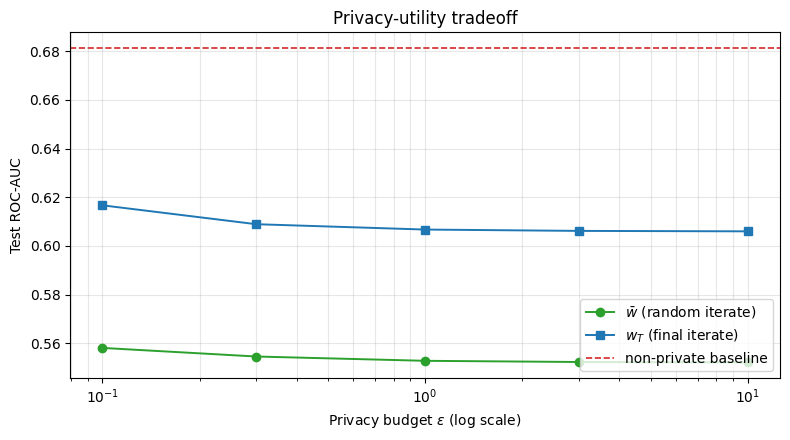

In [7]:
_ = viz.plot_epsilon_sweep(
    EPSILONS, auc_random_list, auc_final_list,
    FIGS_DIR / 'privacy_utility_tradeoff.png',
    auc_baseline=auc_baseline,
)
print({'epsilon': EPSILONS, 'auc_random': auc_random_list,
       'auc_final': auc_final_list, 'auc_baseline': auc_baseline})
